Toplam Özellik Sayısı: 30

[*] Özellik seçimi yapılıyor (ConsensusFS)...

--- SEÇİLEN EN İYİ 5 ÖZELLİK ---
['worst concave points', 'mean concave points', 'worst texture', 'mean perimeter', 'worst radius', 'worst area', 'mean concavity', 'area error', 'worst perimeter', 'mean radius']

--- DETAYLI SKOR TABLOSU ---
                      correlation  permutation      shap      lofo  meta_score
worst concave points     0.788885     0.003956  0.069948 -0.000015        7.25
mean concave points      0.778115     0.001758  0.051295  0.000296        7.50
worst texture            0.467479     0.003077  0.017451  0.004755        7.50
mean perimeter           0.731859     0.000000  0.019804  0.002287        7.75
worst radius             0.766527     0.000000  0.040896  0.001205        7.75
worst area               0.722875     0.001758  0.077109  0.000043        8.75
mean concavity           0.683262     0.000000  0.032576  0.001713        8.75
area error               0.517064     0.001758  0.01

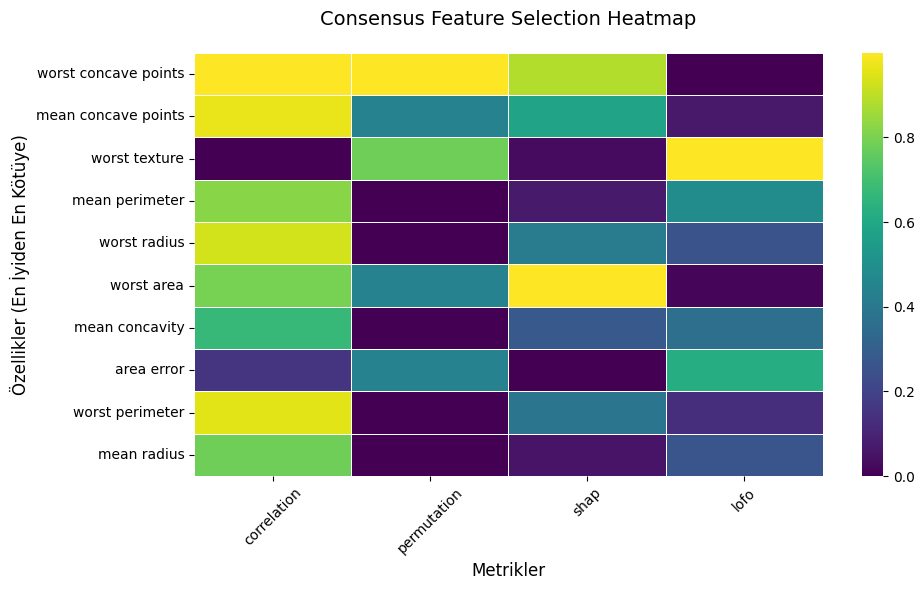

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from consensusfs import ConsensusSelector

# 1. VERİ SETİNİ YÜKLE
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(f"Toplam Özellik Sayısı: {X.shape[1]}")

# Eğitim ve test ayırımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. MODELİ TANIMLA
# Özellik seçimi için güçlü bir model seçelim
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. CONSENSUS SELECTOR'I ÇALIŞTIR
# SHAP, Permutation ve Korelasyonu birleştirelim (Hız için şimdilik LOFO kapalı)
selector = ConsensusSelector(
    estimator=model,
    methods=['correlation', 'permutation', 'shap', 'lofo'],
    n_features_to_select=10, # En önemli 5 özelliği seçmek istiyoruz
    aggregation='rank_mean',
    n_jobs=-1
)

print("\n[*] Özellik seçimi yapılıyor (ConsensusFS)...")
selector.fit(X_train, y_train)

# 4. SONUÇLARI İNCELE
print("\n--- SEÇİLEN EN İYİ 5 ÖZELLİK ---")
print(selector.best_features_)

print("\n--- DETAYLI SKOR TABLOSU ---")
print(selector.importance_df_.head(10))

# 5. PERFORMANS KARŞILAŞTIRMASI
# A) Tüm özelliklerle model eğitimi
model_all = RandomForestClassifier(random_state=42)
model_all.fit(X_train, y_train)
y_pred_all = model_all.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)

# B) Sadece seçilen 5 özellik ile model eğitimi
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

model_sel = RandomForestClassifier(random_state=42)
model_sel.fit(X_train_selected, y_train)
y_pred_sel = model_sel.predict(X_test_selected)
acc_sel = accuracy_score(y_test, y_pred_sel)

print("\n--- PERFORMANS ANALİZİ ---")
print(f"Tüm Özelliklerle (30 adet) Accuracy: {acc_all:.4f}")
print(f"Seçilen Özelliklerle (5 adet) Accuracy: {acc_sel:.4f}")

# 6. GÖRSELLEŞTİRME
print("\n[*] Heatmap oluşturuluyor...")
selector.plot(top_n=10)